# Paketlerin ve Verinin Yüklenmesi

In [3]:
!pip install feature_engine

In [4]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from feature_engine.selection import DropConstantFeatures
import os


# Set random seed
np.random.seed(42)

# Load data
df_raw = pd.read_csv('cars.csv')

# Veri İnceleme

In [5]:
print(f"Dataset shape: {df_raw.shape}")

Dataset shape: (13904, 94)


Feature Engineer kütüphanesi ile 0.99 aynı olan sabit varyanslı kolonlara bakıyorum ve bunların hasar sütunları dışındaki sütunları çıkarıyorum


In [6]:
# Identify Quasi-constant features
constant_dropper = DropConstantFeatures(tol=0.99, missing_values='ignore')
constant_dropper.fit(df_raw)

print(f"Quasi-constant columns to drop (tol=0.99): {constant_dropper.features_to_drop_}")

Quasi-constant columns to drop (tol=0.99): ['kb_condition', 'gb_usage_type', 'gb_is_first_owner', 'tavan_degisen', 'tavan_boyali', 'tavan_lokal', 'bagaj_degisen', 'bagaj_boyali', 'bagaj_lokal', 'fender_rl_degisen', 'fender_rr_degisen']


Burada 'kb_condition', 'gb_usage_type', 'gb_is_first_owner' değişkenlerini çıkaracağım.

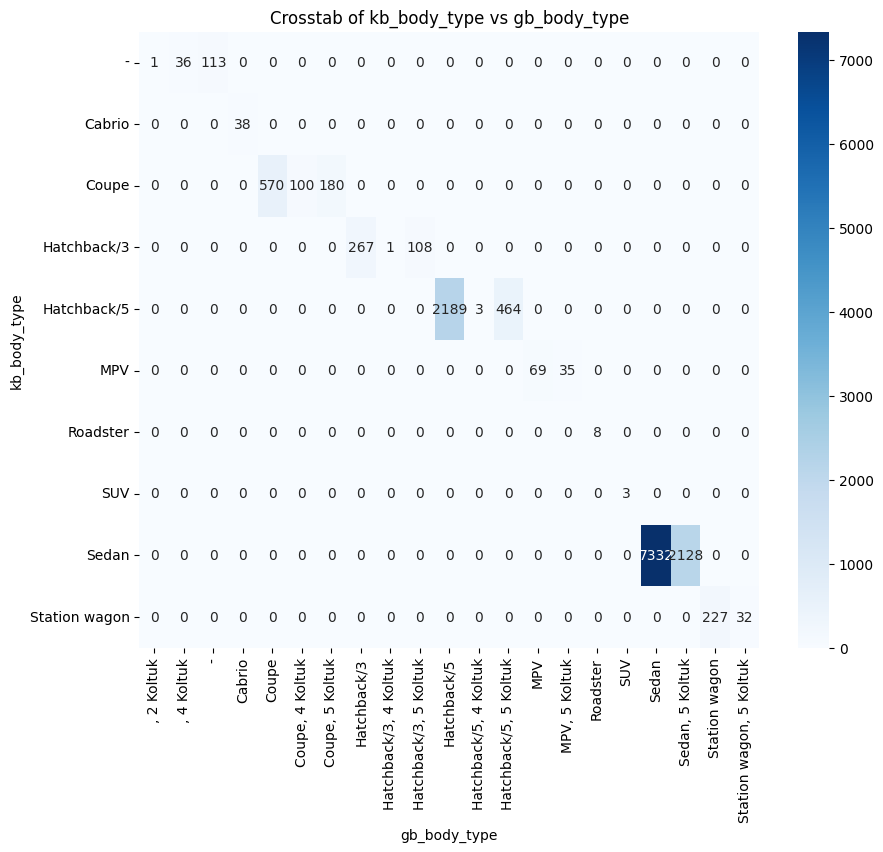

In [7]:
plt.figure(figsize=(10, 8))
body_type_crosstab = pd.crosstab(df_raw['kb_body_type'], df_raw['gb_body_type'])
sns.heatmap(body_type_crosstab, annot=True, fmt='d', cmap='Blues')
plt.title('Crosstab of kb_body_type vs gb_body_type')
plt.xlabel('gb_body_type')
plt.ylabel('kb_body_type')
plt.show()

Daha genel form için kb_body_type değişkenini alacağım

In [8]:
print("Checking for identical columns in the dataset...")

# Dictionary to store groups of identical columns
identical_groups = {}
cols = df_raw.columns.tolist()

# Track columns already assigned to a group to avoid redundant checks
checked = set()

for i in range(len(cols)):
    col1 = cols[i]
    if col1 in checked:
        continue

    current_group = [col1]
    for j in range(i + 1, len(cols)):
        col2 = cols[j]
        if col2 in checked:
            continue

        # Check if columns are equal (pandas .equals() handles NaNs correctly)
        if df_raw[col1].equals(df_raw[col2]):
            current_group.append(col2)
            checked.add(col2)

    if len(current_group) > 1:
        identical_groups[col1] = current_group

if identical_groups:
    print("\nFound identical columns:")
    for key, group in identical_groups.items():
        print(f"  - Group: {group}")
else:
    print("\nNo perfectly identical columns found.")

Checking for identical columns in the dataset...

Found identical columns:
  - Group: ['kb_year', 'gb_year']
  - Group: ['kb_mileage', 'gb_mileage']
  - Group: ['kb_transmission', 'gb_transmission']
  - Group: ['kb_fuel', 'gb_fuel']
  - Group: ['kb_color', 'gb_color']
  - Group: ['kb_is_heavy_damaged', 'is_heavy_damaged']
  - Group: ['bagaj_degisen', 'bagaj_boyali', 'bagaj_lokal']


Tekrarlı değişkenleri çıkaracağım. Farklı bölümlerden alınan aynı veriler sadece bagaj değişkenlerini bırakacağım fakat unutulmamalıdır ki aynı arabada bu üç durumun var olmasına gerek yoktur. Değişen yeterlidir.


--- Missing Values Heatmap ---


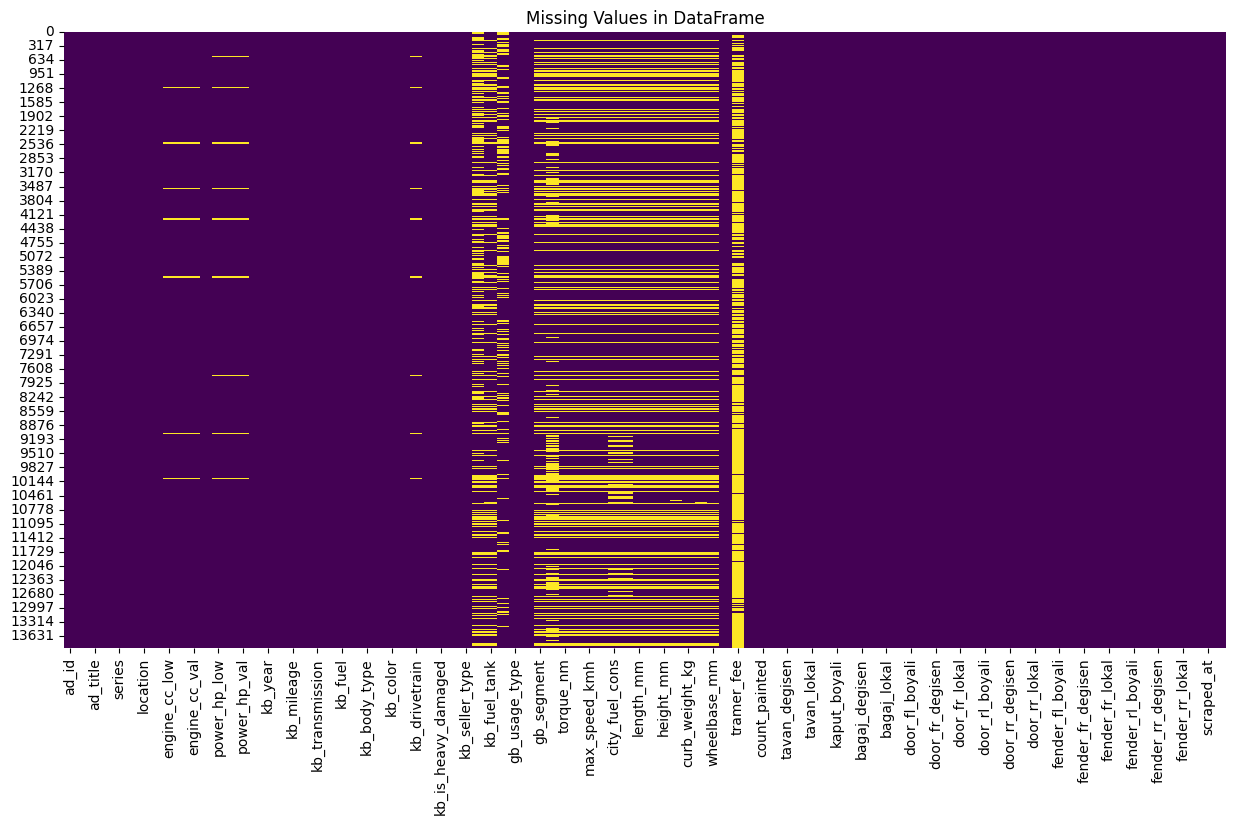

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Missing Values Heatmap ---")
plt.figure(figsize=(15, 8))
sns.heatmap(df_raw.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values in DataFrame')
plt.show()

Eksik gözlemleri hiyerarşik doldurmaya gidilebilir ama şuanlık doldurmayıp direk sütunları silmeyi planlıyorum. Model ve yıl bazlı doldurulabilir.

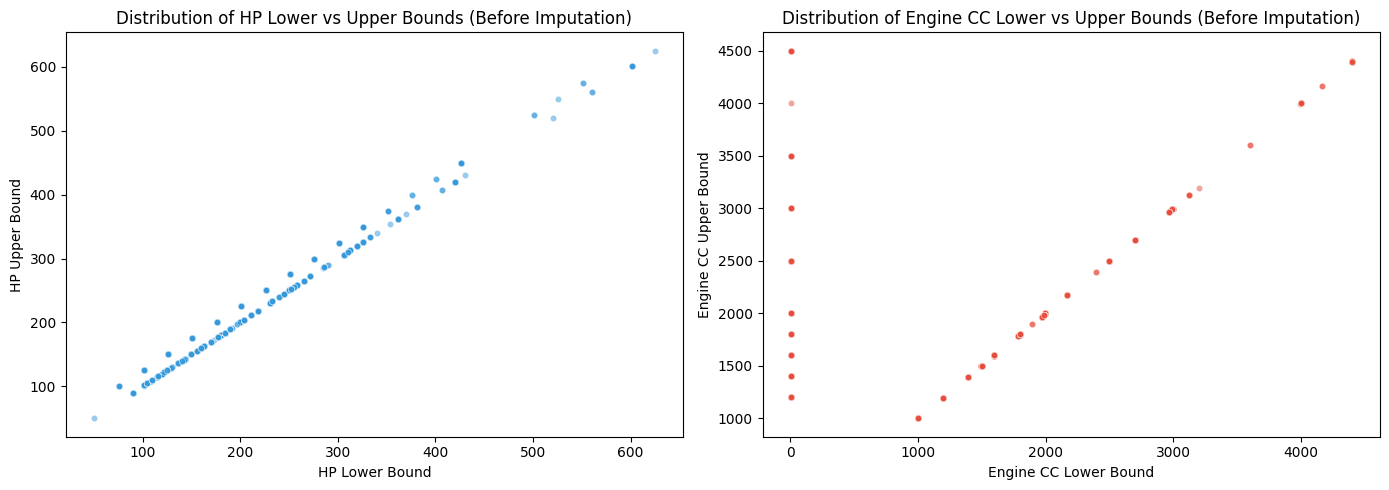

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot for Horsepower
sns.scatterplot(data=df_raw, x='power_hp_low', y='power_hp_up',
                alpha=0.5, color='#3498db', s=20, ax=axes[0])
axes[0].set_title('Distribution of HP Lower vs Upper Bounds (Before Imputation)')
axes[0].set_xlabel('HP Lower Bound')
axes[0].set_ylabel('HP Upper Bound')

# 2. Plot for Engine CC
sns.scatterplot(data=df_raw, x='engine_cc_low', y='engine_cc_up',
                alpha=0.5, color='#e74c3c', s=20, ax=axes[1])
axes[1].set_title('Distribution of Engine CC Lower vs Upper Bounds (Before Imputation)')
axes[1].set_xlabel('Engine CC Lower Bound')
axes[1].set_ylabel('Engine CC Upper Bound')

plt.tight_layout()
plt.show()

Burada aralık verilen beygir ve cc değerleri için low ve up kullanıldı bu yüzden bunların ortalamaları alacağım fakat cc için grafikte görüldüğü üzere 3 gibi değerler girilmiş onun yerine üst sınırdaki değeri alacağım

In [11]:
# 1. Calculate boundary means
df_raw['power_hp_val'] = df_raw[['power_hp_low', 'power_hp_up']].mean(axis=1)
df_raw['engine_cc_val'] = df_raw['engine_cc_up']

print(f"Remaining missing values in power_hp_val after boundary mean: {df_raw['power_hp_val'].isnull().sum()}")
print(f"Remaining missing values in engine_cc_val after boundary mean: {df_raw['engine_cc_val'].isnull().sum()}")

# 3. Drop quasi-constant, boundary columns, and highly correlated redundant columns
boundary_cols = ['power_hp_low', 'power_hp_up', 'engine_cc_low', 'engine_cc_up']
quasi_constant_cols = ['kb_condition', 'gb_usage_type', 'gb_is_first_owner']
info_cols = ['ad_id','listing_date','ad_title','location','power_hp_is_range','power_hp_is_range', 'description_text', 'scraped_at', 'search_date']
identical_cols = ['kb_year','kb_mileage','kb_transmission','kb_fuel','kb_color','kb_is_heavy_damaged']

cols_to_drop = list(set(quasi_constant_cols + boundary_cols + info_cols + identical_cols))
cols_to_drop = [c for c in cols_to_drop if c in df_raw.columns]

df_raw = df_raw.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns.\n")
print(f"Dataset shape after dropped features: {df_raw.shape}")

Remaining missing values in power_hp_val after boundary mean: 218
Remaining missing values in engine_cc_val after boundary mean: 185
Dropped 21 columns.

Dataset shape after dropped features: (13904, 73)


Bilgi ve çok boş sütunları çıkaracağım

In [12]:
df_raw = df_raw.drop(columns = ['gb_body_type',
       'gb_color', 'kb_drivetrain', 'kb_trade_available', 'kb_seller_type',
       'kb_fuel_cons_avg', 'kb_fuel_tank', 'gb_warranty_status',
       'gb_mtv_yearly', 'torque_nm', 'cylinder_count', 'max_speed_kmh',
       'accel_0_100', 'city_fuel_cons', 'highway_fuel_cons', 'length_mm',
       'width_mm', 'height_mm', 'weight_kg', 'curb_weight_kg',
       'trunk_capacity_lt', 'wheelbase_mm', 'tramer_fee','engine_cc_is_range'])
       # burada kirli ve tekrarlı kolonlar var
       # ve bazı kolonlar

=== Phase 1c: Categorical Feature Relationship Analysis ===
Computing association matrices for 8 categorical features. This might take a few seconds...


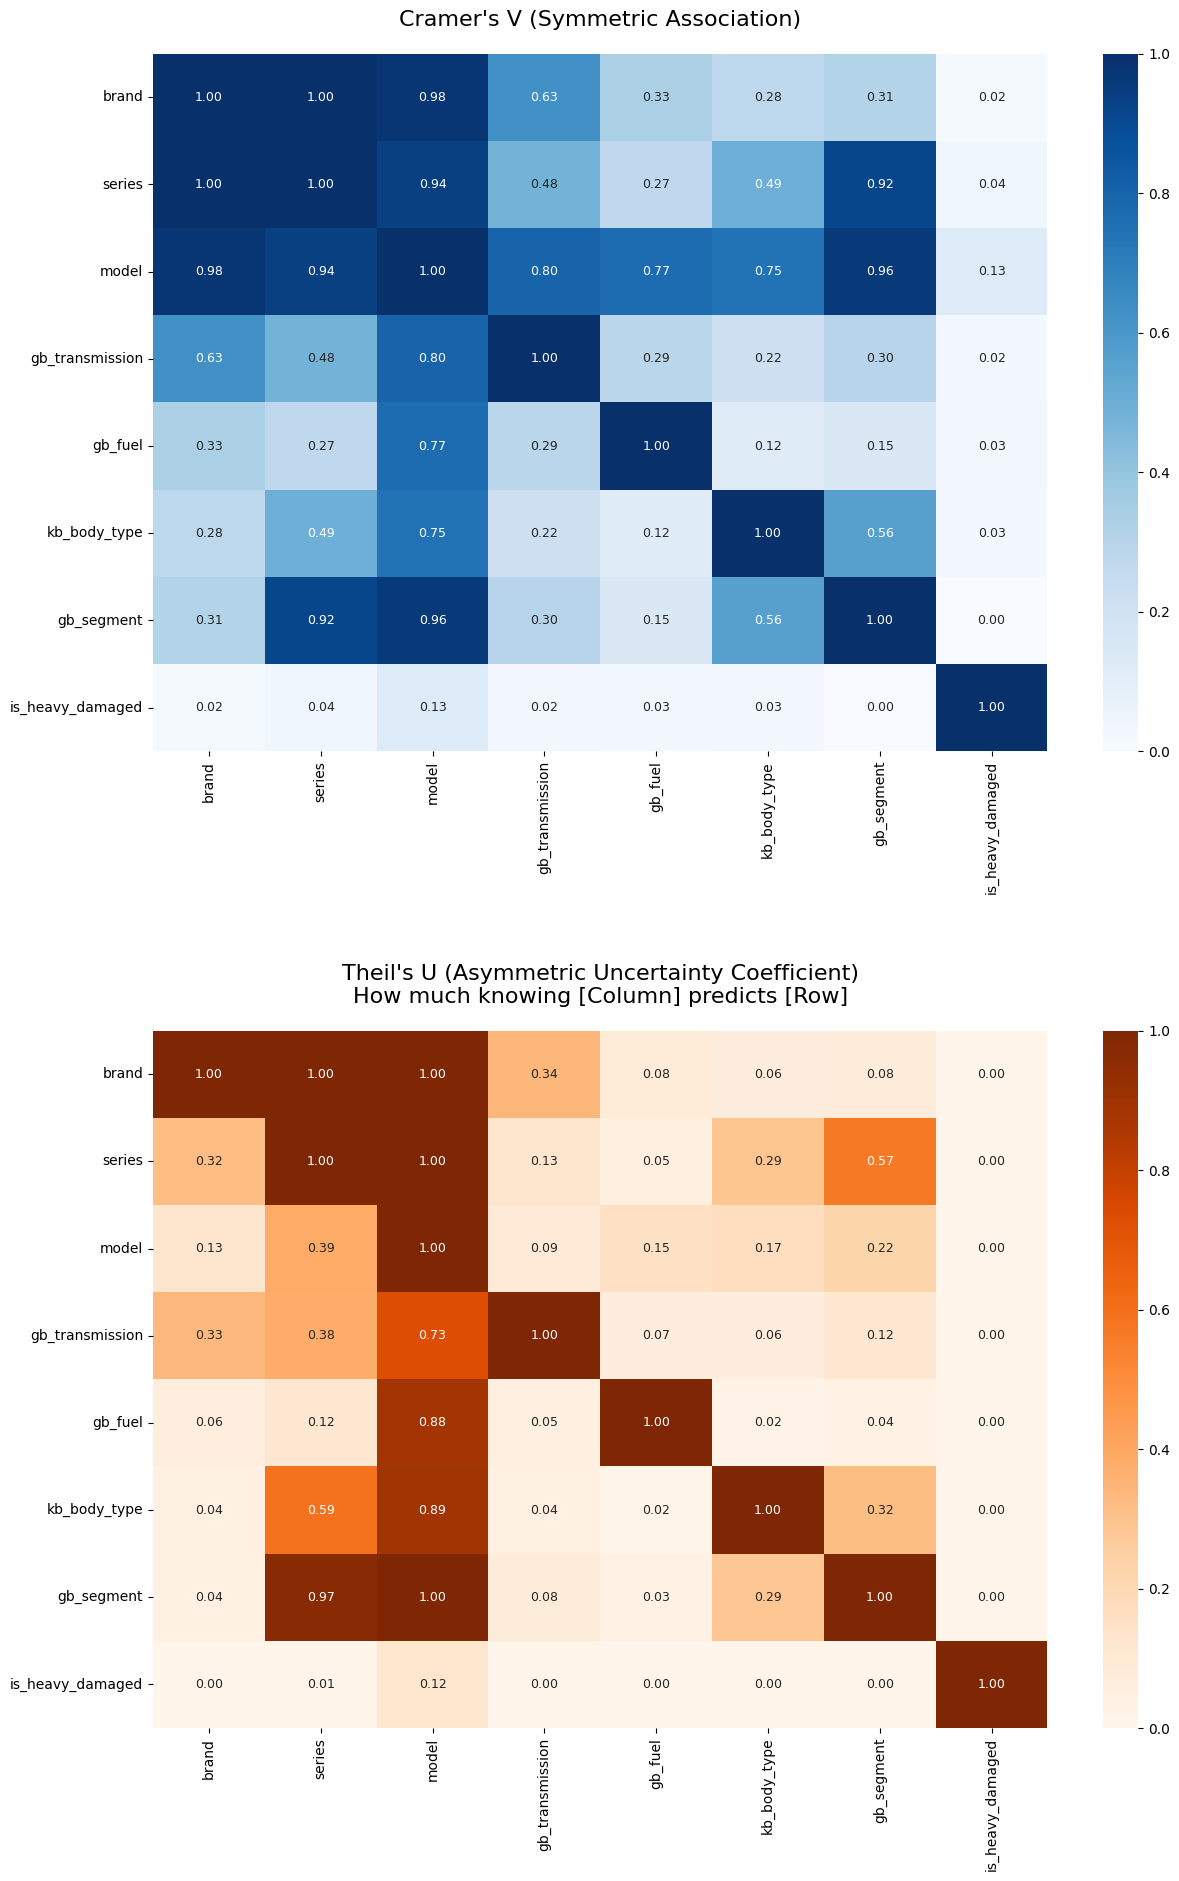


--- Interpretation ---
1. Cramer's V is a SYMMETRIC metric. It evaluates the overall correlation.
2. Theil's U is an ASYMMETRIC metric. U(Row|Column) shows how much the Column explains the Row.
3. High values (close to 1.0) indicate strong redundancy or predictive power.

=== Top Categorical Associations (Cramer's V > 0.8) ===
  - brand & series: 0.999
  - brand & model: 0.977
  - model & gb_segment: 0.961
  - series & model: 0.941
  - series & gb_segment: 0.915

=== Top Categorical Associations (Theil's U > 0.8) ===
  - Knowing 'model' predicts 'brand': 1.000
  - Knowing 'series' predicts 'brand': 1.000
  - Knowing 'model' predicts 'series': 0.999
  - Knowing 'model' predicts 'gb_segment': 0.996
  - Knowing 'series' predicts 'gb_segment': 0.969
  - Knowing 'model' predicts 'kb_body_type': 0.891
  - Knowing 'model' predicts 'gb_fuel': 0.881


In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss
from sklearn.metrics import mutual_info_score

print("=== Phase 1c: Categorical Feature Relationship Analysis ===")

# Select categorical columns with a reasonable number of unique values
cat_cols = df_raw.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
exclude_cats = ['ad_title', 'description_text', 'ad_id', 'listing_date', 'scraped_at', 'search_date', 'location', 'power_hp_is_range']
# Increased the max unique values threshold from 150 to 5000 to include 'model'
cat_cols = [c for c in cat_cols if c not in exclude_cats and df_raw[c].nunique() > 1]

# Function for Cramer's V (Symmetric)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min((kcorr-1), (rcorr-1))
    if denom <= 0:
        return 0.0
    return np.sqrt(phi2corr / denom)

# Function for Theil's U / Uncertainty Coefficient (Asymmetric)
def theils_u(x, y):
    s_xy = pd.crosstab(x, y)
    pi = s_xy.sum(axis=1) / s_xy.sum().sum()
    entropy_x = ss.entropy(pi)
    if entropy_x == 0:
        return 1.0
    mis = mutual_info_score(x, y)
    return mis / entropy_x

# Calculate matrices
n_cats = len(cat_cols)
cv_matrix = pd.DataFrame(np.zeros((n_cats, n_cats)), index=cat_cols, columns=cat_cols)
tu_matrix = pd.DataFrame(np.zeros((n_cats, n_cats)), index=cat_cols, columns=cat_cols)

print(f"Computing association matrices for {n_cats} categorical features. This might take a few seconds...")
for i in range(n_cats):
    for j in range(n_cats):
        col1, col2 = cat_cols[i], cat_cols[j]
        # Drop NA to compute
        valid_idx = df_raw[[col1, col2]].dropna().index
        x = df_raw.loc[valid_idx, col1].astype(str)
        y = df_raw.loc[valid_idx, col2].astype(str)

        if i == j:
            cv_matrix.loc[col1, col2] = 1.0
            tu_matrix.loc[col1, col2] = 1.0
        else:
            cv_matrix.loc[col1, col2] = cramers_v(x, y)
            # Theil's U is asymmetric: U(x|y) - How much y explains x
            tu_matrix.loc[col1, col2] = theils_u(x, y)

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(14, 20))

# Cramer's V Heatmap
sns.heatmap(cv_matrix,
            annot=True,      # Added: Show values
            fmt=".2f",       # Added: 2 decimal places
            cmap="Blues",
            ax=axes[0],
            vmin=0,
            vmax=1,
            annot_kws={"size": 9}) # Optional: Adjust font size for clarity
axes[0].set_title("Cramer's V (Symmetric Association)", fontsize=16, pad=20)

# Theil's U Heatmap
sns.heatmap(tu_matrix,
            annot=True,      # Added: Show values
            fmt=".2f",       # Added: 2 decimal places
            cmap="Oranges",
            ax=axes[1],
            vmin=0,
            vmax=1,
            annot_kws={"size": 9}) # Optional: Adjust font size for clarity
axes[1].set_title("Theil's U (Asymmetric Uncertainty Coefficient)\nHow much knowing [Column] predicts [Row]", fontsize=16, pad=20)

plt.tight_layout(pad=5.0) # Added padding to prevent title overlap
plt.show()

# --- Interpretation ---
print("\n--- Interpretation ---")
print("1. Cramer's V is a SYMMETRIC metric. It evaluates the overall correlation.")
print("2. Theil's U is an ASYMMETRIC metric. U(Row|Column) shows how much the Column explains the Row.")
print("3. High values (close to 1.0) indicate strong redundancy or predictive power.")

# Highly Related Variables Printout
print("\n=== Top Categorical Associations (Cramer's V > 0.8) ===")
high_cv_pairs = []
for i in range(len(cv_matrix.columns)):
    for j in range(i + 1, len(cv_matrix.columns)):
        val = cv_matrix.iloc[i, j]
        if val > 0.8:
            high_cv_pairs.append((cv_matrix.columns[i], cv_matrix.columns[j], val))

high_cv_pairs.sort(key=lambda x: x[2], reverse=True)
if high_cv_pairs:
    for col1, col2, val in high_cv_pairs:
        print(f"  - {col1} & {col2}: {val:.3f}")
else:
    print("  None found.")

print("\n=== Top Categorical Associations (Theil's U > 0.8) ===")
high_tu_pairs = []
for i in range(len(tu_matrix.columns)):
    for j in range(len(tu_matrix.columns)):
        if i == j: continue
        val = tu_matrix.iloc[i, j]
        if val > 0.8:
            high_tu_pairs.append((tu_matrix.index[i], tu_matrix.columns[j], val))

high_tu_pairs.sort(key=lambda x: x[2], reverse=True)
if high_tu_pairs:
    for target, predictor, val in high_tu_pairs:
        print(f"  - Knowing '{predictor}' predicts '{target}': {val:.3f}")
else:
    print("  None found.")


Theils's U matrisi bana özellikle modelin bilindiğinde seri ve markanın tespit edebileceğimizi gösteriyor. İkinci olarak model bilindiğinde kasa tipinin yakıt tipinin ve şanzıman tipinin de tahmin edilebileceğini gösteriyor.

In [14]:
import pandas as pd

def preprocess_damage_score(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate an aggregated 'expert_risk_score' based on the condition of various car parts
    and remove the original sparse expertise columns.

    Parameters:
    -----------
    df : pd.DataFrame
        The input DataFrame containing vehicle expertise data.

    Returns:
    --------
    pd.DataFrame
        The modified DataFrame with the new 'expert_risk_score' column and without the
        original expertise condition columns.

    Details:
    --------
    Penalty points are assigned based on the severity of the damage:
    - Roof (tavan): Replaced = 150, Painted = 75, Locally Painted = 40
    - Hood (kaput): Replaced = 60, Painted = 30, Locally Painted = 15
    - Trunk (bagaj): Replaced = 40, Painted = 20, Locally Painted = 10
    - Doors (door_*): Replaced = 10, Painted = 5, Locally Painted = 2
    - Fenders (fender_*): Replaced = 8, Painted = 4, Locally Painted = 2
    """
    df_out = df.copy()

    # Identify relevant columns
    door_cols = [c for c in df_out.columns if 'door_' in c]
    fender_cols = [c for c in df_out.columns if 'fender_' in c]

    # Calculate scores using .get() with default 0 to handle missing columns gracefully
    tavan_score = (
        df_out.get('tavan_degisen', 0) * 150 +
        df_out.get('tavan_boyali', 0) * 75 +
        df_out.get('tavan_lokal', 0) * 40
    )

    kaput_score = (
        df_out.get('kaput_degisen', 0) * 60 +
        df_out.get('kaput_boyali', 0) * 30 +
        df_out.get('kaput_lokal', 0) * 15
    )

    bagaj_score = (
        df_out.get('bagaj_degisen', 0) * 40 +
        df_out.get('bagaj_boyali', 0) * 20 +
        df_out.get('bagaj_lokal', 0) * 10
    )

    doors_score = 0
    if door_cols:
        doors_degisen = df_out[[c for c in door_cols if 'degisen' in c]].sum(axis=1) if any('degisen' in c for c in door_cols) else 0
        doors_boyali = df_out[[c for c in door_cols if 'boyali' in c]].sum(axis=1) if any('boyali' in c for c in door_cols) else 0
        doors_lokal = df_out[[c for c in door_cols if 'lokal' in c]].sum(axis=1) if any('lokal' in c for c in door_cols) else 0
        doors_score = doors_degisen * 10 + doors_boyali * 5 + doors_lokal * 2

    fenders_score = 0
    if fender_cols:
        fenders_degisen = df_out[[c for c in fender_cols if 'degisen' in c]].sum(axis=1) if any('degisen' in c for c in fender_cols) else 0
        fenders_boyali = df_out[[c for c in fender_cols if 'boyali' in c]].sum(axis=1) if any('boyali' in c for c in fender_cols) else 0
        fenders_lokal = df_out[[c for c in fender_cols if 'lokal' in c]].sum(axis=1) if any('lokal' in c for c in fender_cols) else 0
        fenders_score = fenders_degisen * 8 + fenders_boyali * 4 + fenders_lokal * 2

    # Total score
    df_out['expert_risk_score'] = tavan_score + kaput_score + bagaj_score + doors_score + fenders_score

    # Clean up: Drop the original detail columns
    cols_to_drop = [
        c for c in df_out.columns
        if any(x in c for x in ['tavan_', 'kaput_', 'bagaj_', 'door_', 'fender_'])
    ]
    df_out.drop(columns=cols_to_drop, inplace=True)

    return df_out

# Apply the function to the dataset
df_raw = preprocess_damage_score(df_raw)


In [15]:
df_raw = df_raw.drop(columns = ['gb_segment'])
# Segment kolonu da kirli bazen farklı seri isimlendirmeleri var ve bilgi içerimi açısından model seri gibi değişkenler içerdiği için çıkaracağım

# Tüm Regresyon Modellerini Kurma


### Veri Nasıl Önişlendi
### Hedef Değişken Dönüşümü
- `price` → `log1p(price)`
- **Amaç:** Sağa çarpık fiyat dağılımını normalleştirmek, büyük değerlerin (lüks araç) modele etkisini dengelemek
- Tahminler sonunda `expm1()` ile orijinal ölçeğe döndürüldü
### Kategorik Kodlama
#### a) Target Encoding → `model` kolonu
- Her model kategorisi, o modele ait araçların **ortalama log(fiyat)** değeriyle temsil edildi
- `sklearn.TargetEncoder(smooth='auto')` → Empirical Bayes smoothing
  - Az gözlemli modellerde global ortalamaya doğru çekme yapılır
- `fit_transform()` eğitimde **dahili cross-fitting** uygular
  - Aynı gözlem hem encoding'i hem de modeli eğitmez → **data leakage yok**
- Yüksek kardinalite (çok model çeşidi) için OHE'den üstün

#### b) One-Hot Encoding → `brand` kolonu
- Sadece 2 kategori (Audi / BMW) → `drop='first'` ile **1 dummy kolon** üretildi
- `brand_bmw = 0` → Audi, `brand_bmw = 1` → BMW
- **Dummy variable trap** ve multikollinearite önlendi
- `handle_unknown='ignore'`: test'te görülmemiş marka → sıfır vektörü

### 4. Ölçekleme — `StandardScaler`
- Tüm özellikler: $(x - \mu) / \sigma$ → mean = 0, std = 1
- Scaler **yalnızca train'e fit** edildi, test'e `transform` uygulandı
- **Amaç:** Farklı ölçekteki değişkenlerin (km vs yıl vs hp) katsayılarını karşılaştırılabilir hale getirmek

### 5. Çapraz Doğrulama — 5-Fold KFold
- Veri 5 eşit parçaya bölündü; her fold'da 4 parça train, 1 parça test
- Her fold kendi encoder + scaler'ını bağımsız fit etti → **leakage yok**
- Raporlanan metrikler: **MSE, RMSE, MAE, R²** — 5 fold ortalaması


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')


In [17]:
# ─────────────────────────────────────────────────────────────
# VERİ HAZIRLAMA
# ─────────────────────────────────────────────────────────────
target_variable    = 'price'
target_encode_cols = ['model']
onehot_encode_cols = ['brand']

exclude_cols = [target_variable] + target_encode_cols + onehot_encode_cols
numerical_features = [
    col for col in df_raw.select_dtypes(include=np.number).columns
    if col not in exclude_cols
]

all_features = target_encode_cols + onehot_encode_cols + numerical_features
df_model     = df_raw[all_features + [target_variable]].dropna()

X     = df_model[all_features]
y     = df_model[target_variable]
y_log = np.log1p(y)

print(f"X : {X.shape} | y min: {y.min():,.0f} | y max: {y.max():,.0f}")
print(f"Numerik özellikler ({len(numerical_features)}): {numerical_features}")


X : (13682, 10) | y min: 330,000 | y max: 6,500,000
Numerik özellikler (8): ['engine_cc_val', 'power_hp_val', 'gb_year', 'gb_mileage', 'count_changed', 'count_painted', 'count_local_painted', 'expert_risk_score']


In [18]:
# ─────────────────────────────────────────────────────────────
# PREPROCESSOR
# ─────────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('te',  TargetEncoder(smooth='auto', target_type='continuous', random_state=42),
                target_encode_cols),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
                onehot_encode_cols),
        ('num', StandardScaler(),
                numerical_features),
    ],
    remainder='drop'
)


In [19]:
# ─────────────────────────────────────────────────────────────
# YARDIMCI FONKSİYONLAR
# ─────────────────────────────────────────────────────────────
def get_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return mse, np.sqrt(mse), mean_absolute_error(y_true, y_pred), r2_score(y_true, y_pred)

def add_result(df, name, y_true, y_pred, parameters):
    mse, rmse, mae, r2 = get_metrics(y_true, y_pred)
    df.loc[len(df)] = [name, round(mse,2), round(rmse,2), round(mae,2), round(r2,4), parameters]
    print(f"  {name:55s} | MSE:{mse:>14,.0f} | RMSE:{rmse:>10,.0f} | MAE:{mae:>10,.0f} | R²:{r2:>7.4f} | {parameters:55s}")

def plot_lm_residual(y_true, y_pred, model_name, axes):
    residuals = y_true - y_pred
    axes[0].scatter(y_true, y_pred, alpha=0.35, s=12, color='steelblue')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[0].plot(
    lims, lims, 'r--', lw=1.5, label='Mükemmel tahmin'
    )
    axes[0].set_xlabel('Gerçek Fiyat'); axes[0].set_ylabel('Tahmin')
    axes[0].set_title(f'{model_name}\nActual vs Predicted'); axes[0].legend(fontsize=8)
    axes[1].scatter(y_pred, residuals, alpha=0.35, s=12, color='coral')
    axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
    axes[1].set_xlabel('Tahmin'); axes[1].set_ylabel('Residual')
    axes[1].set_title(f'{model_name}\nResidual Plot')

def make_pipeline(model):
    return Pipeline([('pre', preprocessor), ('model', model)])

def run_cv(pipeline, X, y_log, cv):
    return -cross_val_score(
        pipeline, X, y_log,
        cv=cv, scoring='neg_mean_squared_error', n_jobs=-1
    ).mean()

def fit_predict(pipeline, X_train, y_train_log, X_test):
    """Fit et, log skalada tahmin yap, orijinal skalaya çevir."""
    pipeline.fit(X_train, y_train_log)
    return np.expm1(pipeline.predict(X_test))

In [20]:
def plot_lm_residual(y_true, y_pred, model_name, axes):
    # Artıkları (Residuals) hesapla
    residuals = y_true - y_pred

    # --- 1. Grafik: Actual vs Predicted (Regplot ile) ---
    sns.regplot(
        x=y_true,
        y=y_pred,
        ax=axes[0],
        scatter_kws={'alpha': 0.35, 's': 12, 'color': 'steelblue'},
        line_kws={'color': 'darkblue', 'lw': 1.5, 'label': 'Trend (Regresyon)'}
    )

    # Mükemmel tahmin çizgisi (y = x doğrultusu)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[0].plot(lims, lims, 'r--', lw=1.5, label='Mükemmel Tahmin')

    axes[0].set_xlabel('Gerçek Fiyat')
    axes[0].set_ylabel('Tahmin')
    axes[0].set_title(f'{model_name}\nActual vs Predicted')
    axes[0].legend(fontsize=8)

    # --- 2. Grafik: Residual Plot ---
    sns.scatterplot(
        x=y_pred,
        y=residuals,
        ax=axes[1],
        alpha=0.35,
        s=12,
        color='coral'
    )
    axes[1].axhline(0, color='red', linestyle='--', lw=1.5)

    axes[1].set_xlabel('Tahmin Edilen Değer')
    axes[1].set_ylabel('Artık (Residual)')
    axes[1].set_title(f'{model_name}\nResidual Plot')

In [21]:
# ─────────────────────────────────────────────────────────────
# SON FOLD
# ─────────────────────────────────────────────────────────────
kf    = KFold(n_splits=5, shuffle=True, random_state=42)
folds = list(kf.split(X, y_log))
train_index, test_index = folds[-1]

X_train, X_test     = X.iloc[train_index],     X.iloc[test_index]
y_train, y_test     = y.iloc[train_index],     y.iloc[test_index]
y_train_log         = np.log1p(y_train)
y_test_orig         = y_test.values

cv_inner = KFold(n_splits=5, shuffle=True, random_state=42)

evaluation_results = pd.DataFrame(columns=['Model','MSE','RMSE','MAE','R2','Parameters'])
predictions        = {}

## Lineer Regresyon

In [22]:
# ── 1) Lineer Regresyon ──────────────────────────────────────
pipe_lr = make_pipeline(LinearRegression())
predictions['Lineer Regresyon'] = fit_predict(pipe_lr, X_train, y_train_log, X_test)
add_result(evaluation_results, 'Lineer Regresyon', y_test_orig, predictions['Lineer Regresyon'],"Default")

  Lineer Regresyon                                        | MSE:134,069,346,197 | RMSE:   366,155 | MAE:   221,446 | R²: 0.8891 | Default                                                


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                 1.336e+04
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:31:13   Log-Likelihood:                 5603.6
No. Observations:               10946   AIC:                        -1.119e+04
Df Residuals:                   10935   BIC:                        -1.110e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   6.5925    

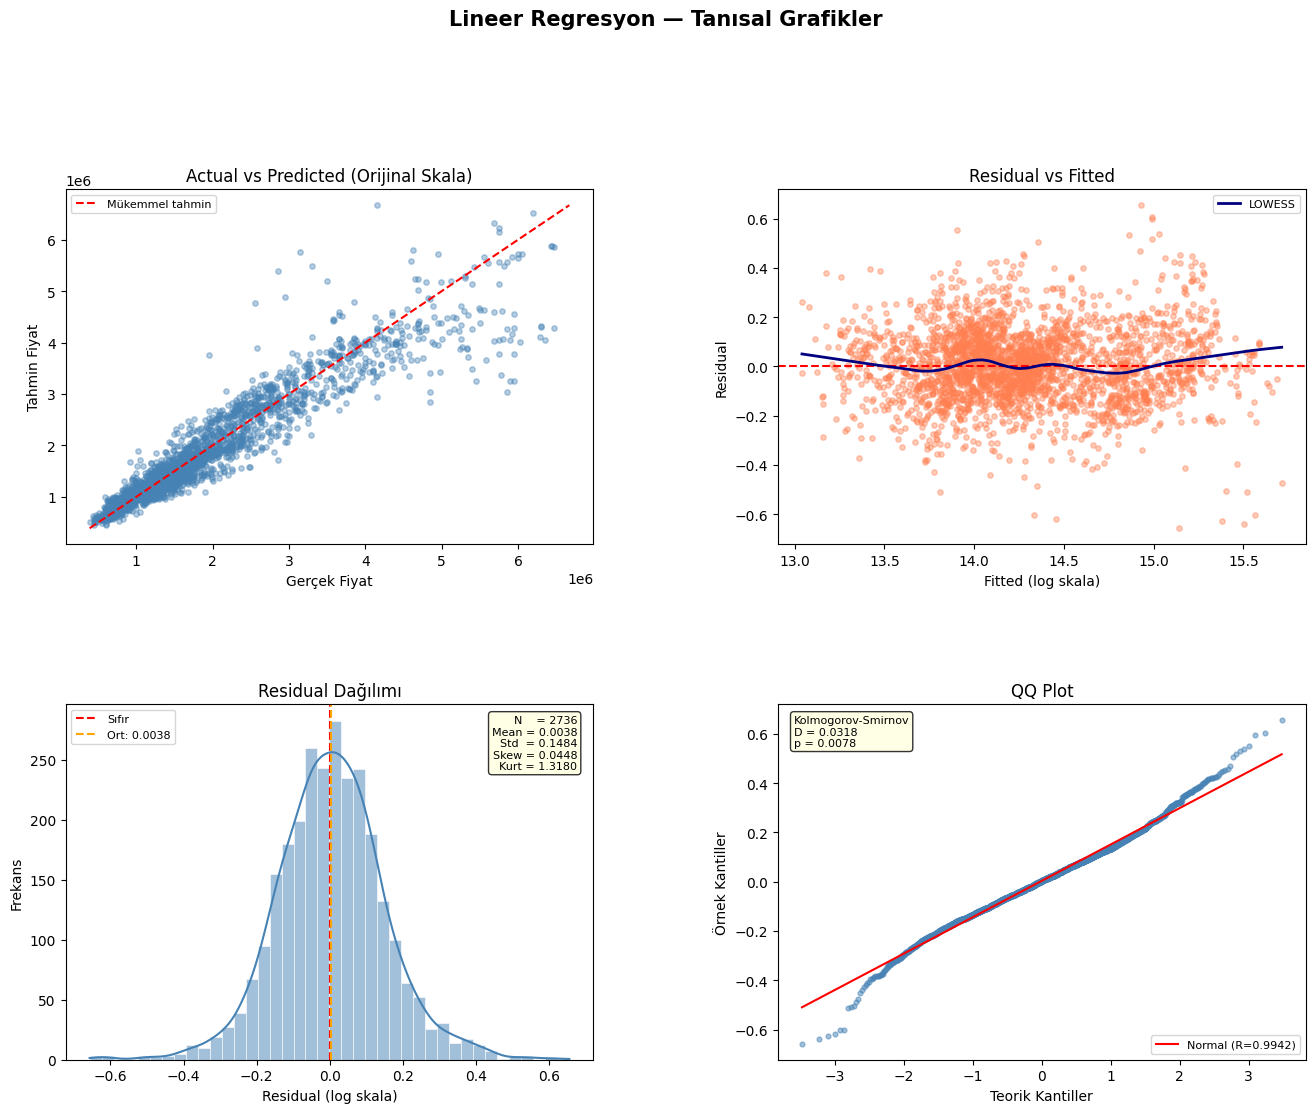


--- Kolmogorov-Smirnov Normallik Testi ---
D  = 0.0318
p  = 0.0078
→  Normallik REDDEDİLİYOR ❌ (α = 0.05)

--- OLS Test Metrikleri (Orijinal Skala) ---
MSE  : 131,954,708,560.51
RMSE :      363,255.71
MAE  :      218,869.57
R²   :          0.8908


In [23]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

# ─────────────────────────────────────────────────────────────
# 1) PREPROCESSOR'dan geçirilmiş train/test verisini al
#    (pipe_lr zaten fit edildi — içindeki pre adımını kullanıyoruz)
# ─────────────────────────────────────────────────────────────
pre_fitted   = pipe_lr.named_steps['pre']
X_train_proc = pre_fitted.transform(X_train)          # numpy array
X_test_proc  = pre_fitted.transform(X_test)

# Kolon isimlerini al
te_cols  = target_encode_cols
ohe_cols = list(pre_fitted.named_transformers_['ohe'].get_feature_names_out(onehot_encode_cols))
num_cols = numerical_features
col_names = te_cols + ohe_cols + num_cols

X_train_df = pd.DataFrame(X_train_proc, columns=col_names)
X_test_df  = pd.DataFrame(X_test_proc,  columns=col_names)

# ─────────────────────────────────────────────────────────────
# 2) STATSMODELS OLS — sabit terim ekle
# ─────────────────────────────────────────────────────────────
X_train_sm = sm.add_constant(X_train_df)
X_test_sm  = sm.add_constant(X_test_df)

sm_model = sm.OLS(y_train_log.values, X_train_sm).fit()
print(sm_model.summary())

# ─────────────────────────────────────────────────────────────
# 3) VIF — intercept hariç
# ─────────────────────────────────────────────────────────────
print("\n--- VIF (Variance Inflation Factor) — Intercept Hariç ---")

# const kolonu çıkar
X_train_vif = X_train_sm.drop(columns=['const'])

vif_df = pd.DataFrame({
    'Feature': X_train_vif.columns,
    'VIF':     [variance_inflation_factor(X_train_vif.values, i)
                for i in range(X_train_vif.shape[1])]
})

def vif_label(v):
    if v < 5:   return '✅ Düşük'
    if v < 10:  return '⚠️  Orta'
    return             '❌ Yüksek'

vif_df['Yorum'] = vif_df['VIF'].apply(vif_label)
vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)
print(vif_df.to_string(index=False))

high_vif = vif_df[vif_df['VIF'] >= 10]
if not high_vif.empty:
    print(f"\n⚠️  Yüksek VIF — {len(high_vif)} değişken multikollinearite riski taşıyor:")
    print(high_vif[['Feature', 'VIF']].to_string(index=False))
else:
    print("\n✅ Tüm VIF < 10 — belirgin multikollinearite yok.")

# ─────────────────────────────────────────────────────────────
# 4) TAHMİN & RESİDUAL (log skala)
# ─────────────────────────────────────────────────────────────
y_pred_log  = sm_model.predict(X_test_sm)
y_pred_orig = np.expm1(y_pred_log)

# Define y_test_log here by transforming y_test
y_test_log = np.log1p(y_test) # FIX: Add this line to define y_test_log

residuals   = y_test_log.values - y_pred_log     # log skalada residual

# ─────────────────────────────────────────────────────────────
# 5) GRAFİKLER  (2x2 + 1 ek = 5 panel)
# ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 18))
fig.suptitle('Lineer Regresyon — Tanısal Grafikler', fontsize=15, fontweight='bold')

gs = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])   # LM Plot
ax2 = fig.add_subplot(gs[0, 1])   # Residual vs Fitted
ax3 = fig.add_subplot(gs[1, 0])   # Residual Hist + KDE
ax4 = fig.add_subplot(gs[1, 1])   # QQ Plot

# ── 5a) LM Plot — Actual vs Predicted (orijinal skala) ───────
ax1.scatter(y_test_orig, y_pred_orig, alpha=0.4, s=15, color='steelblue')
lims = [min(y_test_orig.min(), y_pred_orig.min()),
        max(y_test_orig.max(), y_pred_orig.max())]
ax1.plot(lims, lims, 'r--', lw=1.5, label='Mükemmel tahmin')
ax1.set_xlabel('Gerçek Fiyat'); ax1.set_ylabel('Tahmin Fiyat')
ax1.set_title('Actual vs Predicted (Orijinal Skala)')
ax1.legend(fontsize=8)

# ── 5b) Residual vs Fitted (log skala) ───────────────────────
ax2.scatter(y_pred_log, residuals, alpha=0.4, s=15, color='coral')
ax2.axhline(0, color='red', linestyle='--', lw=1.5)
# LOWESS düzleştirme çizgisi
from statsmodels.nonparametric.smoothers_lowess import lowess
lw_fit = lowess(residuals, y_pred_log, frac=0.3)
ax2.plot(lw_fit[:, 0], lw_fit[:, 1], color='navy', lw=2, label='LOWESS')
ax2.set_xlabel('Fitted (log skala)'); ax2.set_ylabel('Residual')
ax2.set_title('Residual vs Fitted')
ax2.legend(fontsize=8)

# ── 5c) Residual Histogram + KDE ─────────────────────────────
sns.histplot(residuals, kde=True, bins=40, color='steelblue',
             edgecolor='white', linewidth=0.4, ax=ax3)
ax3.axvline(0,               color='red',    linestyle='--', lw=1.5, label='Sıfır')
ax3.axvline(residuals.mean(), color='orange', linestyle='--', lw=1.5,
            label=f'Ort: {residuals.mean():.4f}')
ax3.set_xlabel('Residual (log skala)'); ax3.set_ylabel('Frekans')
ax3.set_title('Residual Dağılımı')
ax3.legend(fontsize=8)

textstr = (f'N    = {len(residuals)}\n'
           f'Mean = {residuals.mean():.4f}\n'
           f'Std  = {residuals.std():.4f}\n'
           f'Skew = {stats.skew(residuals):.4f}\n'
           f'Kurt = {stats.kurtosis(residuals):.4f}')
ax3.text(0.97, 0.97, textstr, transform=ax3.transAxes, fontsize=8,
         va='top', ha='right',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── 5d) QQ Plot ───────────────────────────────────────────────
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
ax4.scatter(osm, osr, color='steelblue', alpha=0.5, s=12)
ax4.plot([osm.min(), osm.max()],
         [slope * osm.min() + intercept, slope * osm.max() + intercept],
         color='red', lw=1.5, label=f'Normal (R={r:.4f})')
ax4.set_xlabel('Teorik Kantiller'); ax4.set_ylabel('Örnek Kantiller')
ax4.set_title('QQ Plot')
ax4.legend(fontsize=8)

# Kolmogorov-Smirnov testi
res_std  = (residuals - residuals.mean()) / residuals.std()
ks_stat, ks_p = stats.kstest(res_std, 'norm')
ax4.text(0.03, 0.97,
         f'Kolmogorov-Smirnov\nD = {ks_stat:.4f}\np = {ks_p:.4f}',
         transform=ax4.transAxes, fontsize=8, va='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.show()

# ─────────────────────────────────────────────────────────────
# 6) TEST SONUÇLARI
# ─────────────────────────────────────────────────────────────
print(f"\n--- Kolmogorov-Smirnov Normallik Testi ---")
print(f"D  = {ks_stat:.4f}")
print(f"p  = {ks_p:.4f}")
print(f"→  Normallik {'REDDEDİLEMEZ ✅' if ks_p > 0.05 else 'REDDEDİLİYOR ❌'} (α = 0.05)")

print(f"\n--- OLS Test Metrikleri (Orijinal Skala) ---")
mse, rmse, mae, r2 = get_metrics(y_test_orig, y_pred_orig)
print(f"MSE  : {mse:>15,.2f}")
print(f"RMSE : {rmse:>15,.2f}")
print(f"MAE  : {mae:>15,.2f}")
print(f"R²   : {r2:>15.4f}")

## PCR


  PCR optimal bileşen (min CV-MSE): 10
  %95 varyans için gereken bileşen: 7


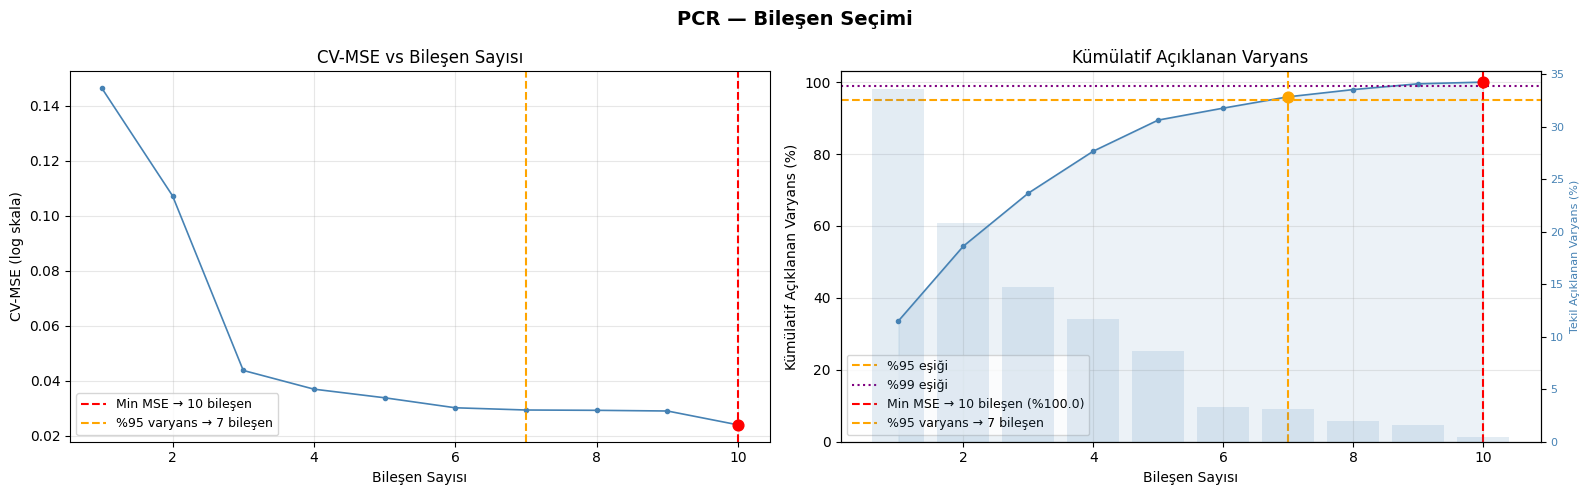


 Bileşen | Tekil Varyans % | Kümülatif %
────────────────────────────────────────
       1 |           33.60 |       33.60
       2 |           20.79 |       54.38
       3 |           14.73 |       69.12
       4 |           11.67 |       80.79
       5 |            8.65 |       89.44
       6 |            3.32 |       92.76
       7 |            3.15 |       95.91 ← %95 eşiği
       8 |            2.01 |       97.92
       9 |            1.61 |       99.53
      10 |            0.47 |      100.00 ← optimal (MSE)
  PCR                                                     | MSE:134,069,346,197 | RMSE:   366,155 | MAE:   221,446 | R²: 0.8891 | (10pc)                                                 


In [24]:
# ── 2) PCR ───────────────────────────────────────────────────
# Önce PCA'yı fit et — varyans bilgisi için
pre_fitted_pcr = Pipeline([('pre', preprocessor)]).fit(X_train, y_train_log)
X_train_pre    = pre_fitted_pcr.named_steps['pre'].transform(X_train)

pca_full = PCA().fit(X_train_pre)
max_components = X_train_pre.shape[1]

# Her n için CV-MSE
mse_pca_list = [
    run_cv(
        Pipeline([('pre', preprocessor), ('pca', PCA(n_components=n)), ('model', LinearRegression())]),
        X_train, y_train_log, cv_inner
    )
    for n in range(1, max_components + 1)
]

optimal_n_pca = np.argmin(mse_pca_list) + 1
print(f"  PCR optimal bileşen (min CV-MSE): {optimal_n_pca}")

# Kümülatif açıklanan varyans
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_95   = np.searchsorted(cumvar, 95) + 1   # %95 eşiğini geçen ilk bileşen
print(f"  %95 varyans için gereken bileşen: {n_95}")

# ── Grafikler ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('PCR — Bileşen Seçimi', fontsize=14, fontweight='bold')

n_range = range(1, max_components + 1)

# Sol: CV-MSE vs n_components
axes[0].plot(n_range, mse_pca_list, marker='o', markersize=3,
             linestyle='-', color='steelblue', linewidth=1.2)
axes[0].axvline(optimal_n_pca, color='red', linestyle='--', linewidth=1.5,
                label=f'Min MSE → {optimal_n_pca} bileşen')
axes[0].axvline(n_95, color='orange', linestyle='--', linewidth=1.5,
                label=f'%95 varyans → {n_95} bileşen')
axes[0].scatter([optimal_n_pca], [mse_pca_list[optimal_n_pca - 1]],
                color='red', zorder=5, s=60)
axes[0].set_xlabel('Bileşen Sayısı')
axes[0].set_ylabel('CV-MSE (log skala)')
axes[0].set_title('CV-MSE vs Bileşen Sayısı')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Sağ: Kümülatif açıklanan varyans
axes[1].plot(n_range, cumvar, marker='o', markersize=3,
             linestyle='-', color='steelblue', linewidth=1.2)
axes[1].fill_between(n_range, cumvar, alpha=0.1, color='steelblue')
axes[1].axhline(95, color='orange', linestyle='--', linewidth=1.5,
                label='%95 eşiği')
axes[1].axhline(99, color='purple', linestyle=':', linewidth=1.5,
                label='%99 eşiği')
axes[1].axvline(optimal_n_pca, color='red', linestyle='--', linewidth=1.5,
                label=f'Min MSE → {optimal_n_pca} bileşen '
                      f'(%{cumvar[optimal_n_pca-1]:.1f})')
axes[1].axvline(n_95, color='orange', linestyle='--', linewidth=1.5,
                label=f'%95 varyans → {n_95} bileşen')
axes[1].scatter([optimal_n_pca], [cumvar[optimal_n_pca - 1]],
                color='red', zorder=5, s=60)
axes[1].scatter([n_95], [cumvar[n_95 - 1]],
                color='orange', zorder=5, s=60)
axes[1].set_xlabel('Bileşen Sayısı')
axes[1].set_ylabel('Kümülatif Açıklanan Varyans (%)')
axes[1].set_title('Kümülatif Açıklanan Varyans')
axes[1].set_ylim(0, 103)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Her bileşenin kendi açıkladığı varyans — bar olarak
ax1b = axes[1].twinx()
ax1b.bar(n_range, pca_full.explained_variance_ratio_ * 100,
         alpha=0.15, color='steelblue', label='Tekil varyans')
ax1b.set_ylabel('Tekil Açıklanan Varyans (%)', color='steelblue', fontsize=8)
ax1b.tick_params(axis='y', labelcolor='steelblue', labelsize=8)

plt.tight_layout()
plt.show()

# Özet tablo
print(f"\n{'Bileşen':>8} | {'Tekil Varyans %':>15} | {'Kümülatif %':>11}")
print("─" * 40)
for i, (indiv, cum) in enumerate(
        zip(pca_full.explained_variance_ratio_ * 100, cumvar), 1):
    marker = ' ← optimal (MSE)' if i == optimal_n_pca else \
             ' ← %95 eşiği'    if i == n_95          else ''
    print(f"{i:>8} | {indiv:>15.2f} | {cum:>11.2f}{marker}")

# ── Final PCR modeli ──────────────────────────────────────────
pipe_pcr = Pipeline([
    ('pre',   preprocessor),
    ('pca',   PCA(n_components=optimal_n_pca)),
    ('model', LinearRegression())
])
predictions[f'PCR ({optimal_n_pca}pc)'] = fit_predict(pipe_pcr, X_train, y_train_log, X_test)
add_result(evaluation_results, 'PCR', y_test_orig, predictions[f'PCR ({optimal_n_pca}pc)'],f"({optimal_n_pca}pc)")

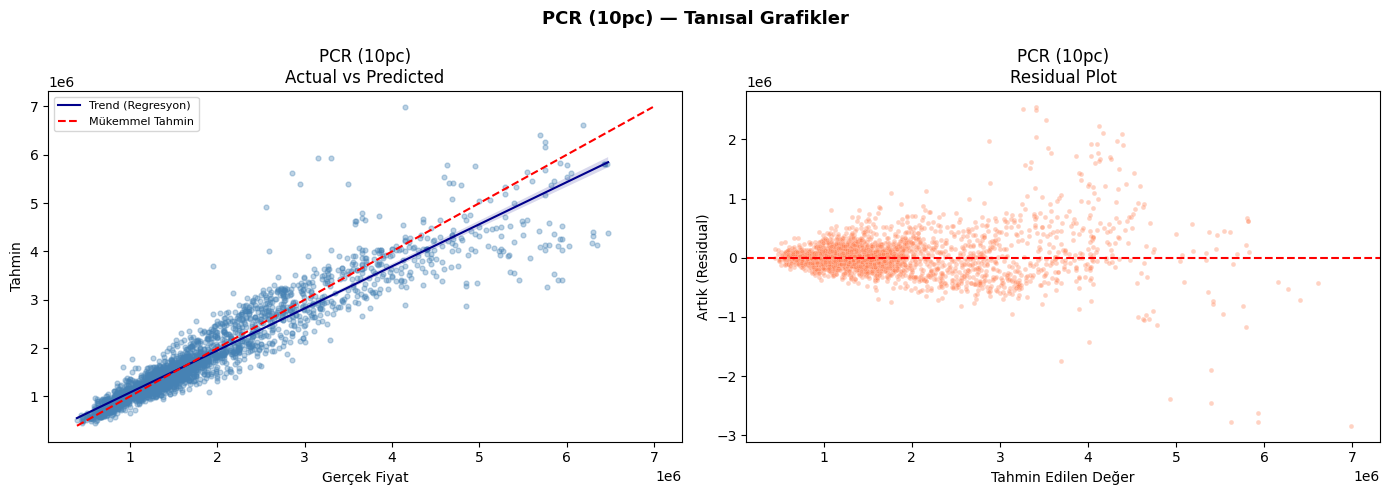

In [25]:
model_name = f'PCR ({optimal_n_pca}pc)'
y_pred     = predictions[model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{model_name} — Tanısal Grafikler', fontsize=13, fontweight='bold')

plot_lm_residual(y_test_orig, y_pred, model_name, axes)

plt.tight_layout()
plt.show()

In [26]:
# ── 3) PLS ───────────────────────────────────────────────────
mse_pls_list = [
    run_cv(Pipeline([('pre', preprocessor), ('model', PLSRegression(n_components=n))]),
           X_train, y_train_log, cv_inner)
    for n in range(1, len(all_features) + 1)
]
optimal_n_pls = np.argmin(mse_pls_list) + 1
print(f"  PLS optimal bileşen: {optimal_n_pls}")
pipe_pls = Pipeline([('pre', preprocessor), ('model', PLSRegression(n_components=optimal_n_pls))])
pipe_pls.fit(X_train, y_train_log)
predictions[f'PLS ({optimal_n_pls}pc)'] = np.expm1(pipe_pls.predict(X_test))
add_result(evaluation_results, 'PLS', y_test_orig, predictions[f'PLS ({optimal_n_pls}pc)'],f' ({optimal_n_pls}pc)')

  PLS optimal bileşen: 7
  PLS                                                     | MSE:134,126,719,915 | RMSE:   366,233 | MAE:   221,567 | R²: 0.8890 |  (7pc)                                                 


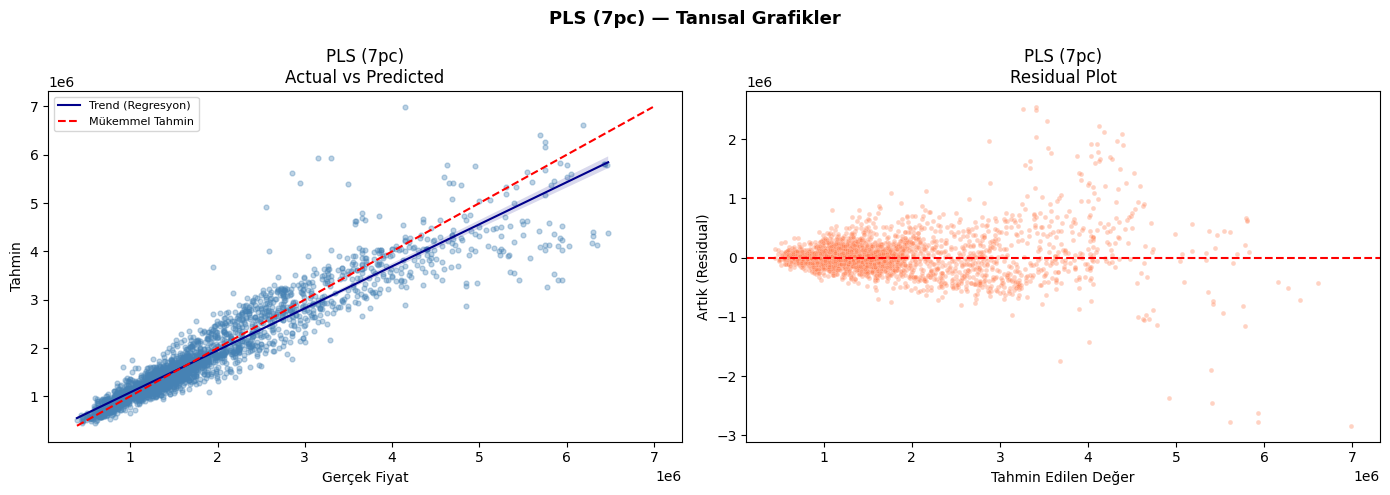

In [27]:
model_name = f'PLS ({optimal_n_pls}pc)'
y_pred     = predictions[model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{model_name} — Tanısal Grafikler', fontsize=13, fontweight='bold')

plot_lm_residual(y_test_orig, y_pred, model_name, axes)

plt.tight_layout()
plt.show()

## Ridge Regression

In [28]:
# ── 4) Ridge ─────────────────────────────────────────────────
ridge_gs = GridSearchCV(
    make_pipeline(Ridge()),
    {'model__alpha': [0.01, 0.1, 1, 10, 100, 500, 1000]},
    cv=cv_inner, scoring='neg_mean_squared_error', n_jobs=-1
)
ridge_gs.fit(X_train, y_train_log)
print(f"\n  Ridge α={ridge_gs.best_params_['model__alpha']}")
predictions['Ridge'] = np.expm1(ridge_gs.best_estimator_.predict(X_test))
add_result(evaluation_results, "Ridge", y_test_orig, predictions['Ridge'],f"(α={ridge_gs.best_params_['model__alpha']})")



  Ridge α=0.01
  Ridge                                                   | MSE:134,069,723,863 | RMSE:   366,155 | MAE:   221,446 | R²: 0.8891 | (α=0.01)                                               


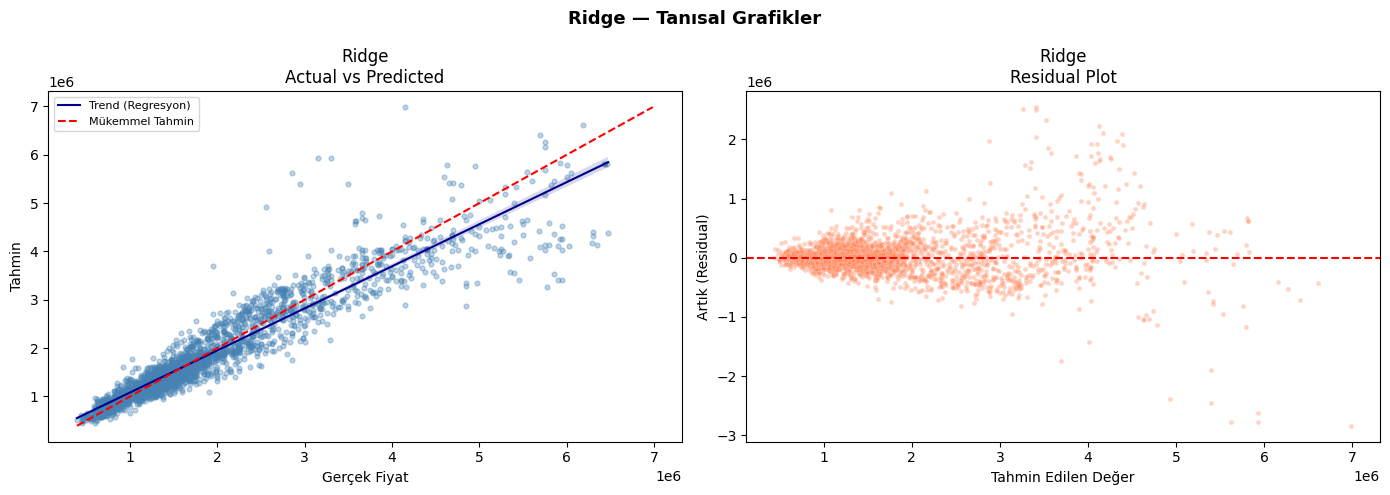

In [29]:
model_name = f'Ridge'
y_pred     = predictions[model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{model_name} — Tanısal Grafikler', fontsize=13, fontweight='bold')

plot_lm_residual(y_test_orig, y_pred, model_name, axes)

plt.tight_layout()
plt.show()

## Lasso

In [30]:
# ── 5) Lasso ─────────────────────────────────────────────────
lasso_gs = GridSearchCV(
    make_pipeline(Lasso(max_iter=10000)),
    {'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]},
    cv=cv_inner, scoring='neg_mean_squared_error', n_jobs=-1
)
lasso_gs.fit(X_train, y_train_log)
print(f"  Lasso α={lasso_gs.best_params_['model__alpha']}")
predictions['Lasso'] = np.expm1(lasso_gs.best_estimator_.predict(X_test))
add_result(evaluation_results, "Lasso", y_test_orig, predictions['Lasso'],f"(α={lasso_gs.best_params_['model__alpha']})")

  Lasso α=0.0001
  Lasso                                                   | MSE:134,156,035,393 | RMSE:   366,273 | MAE:   221,493 | R²: 0.8890 | (α=0.0001)                                             


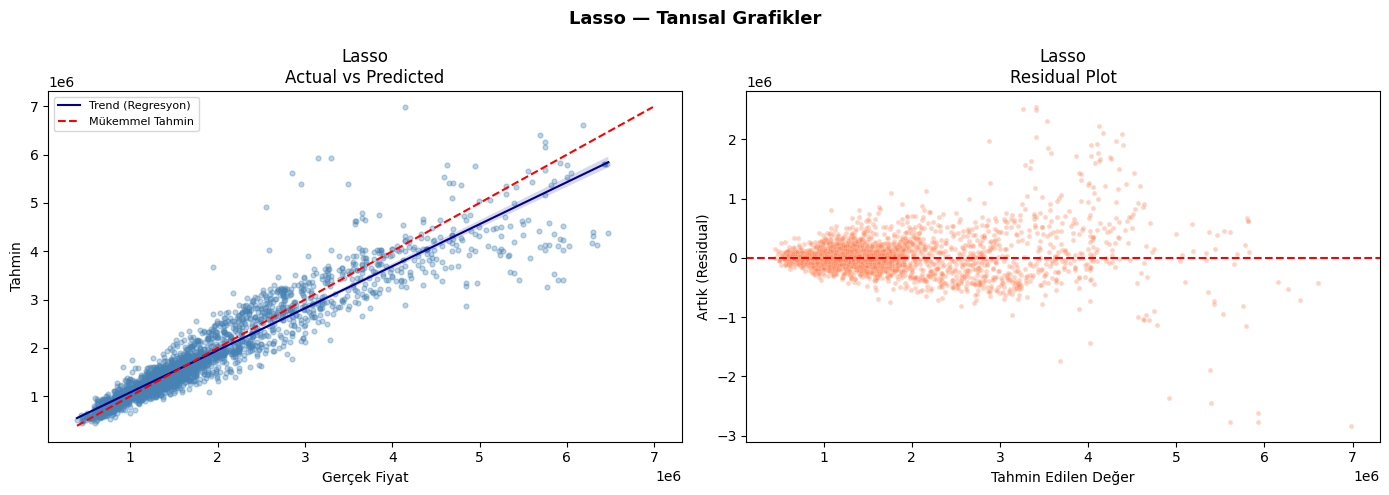

In [31]:
model_name = f'Lasso'
y_pred     = predictions[model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{model_name} — Tanısal Grafikler', fontsize=13, fontweight='bold')

plot_lm_residual(y_test_orig, y_pred, model_name, axes)

plt.tight_layout()
plt.show()

## KNN

In [32]:
# ── 6) KNN ───────────────────────────────────────────────────
knn_gs = GridSearchCV(
    make_pipeline(KNeighborsRegressor()),
    {'model__n_neighbors': [3, 5, 7, 10, 15, 20],
     'model__weights':     ['uniform', 'distance'],
     'model__p':           [1, 2]},
    cv=cv_inner, scoring='neg_mean_squared_error', n_jobs=-1
)
knn_gs.fit(X_train, y_train_log)
print(f"  KNN {knn_gs.best_params_}")
predictions['KNN'] = np.expm1(knn_gs.best_estimator_.predict(X_test))
add_result(evaluation_results, "KNN", y_test_orig, predictions['KNN'], f"{knn_gs.best_params_}")

  KNN {'model__n_neighbors': 15, 'model__p': 1, 'model__weights': 'distance'}
  KNN                                                     | MSE:77,818,817,113 | RMSE:   278,960 | MAE:   174,231 | R²: 0.9356 | {'model__n_neighbors': 15, 'model__p': 1, 'model__weights': 'distance'}


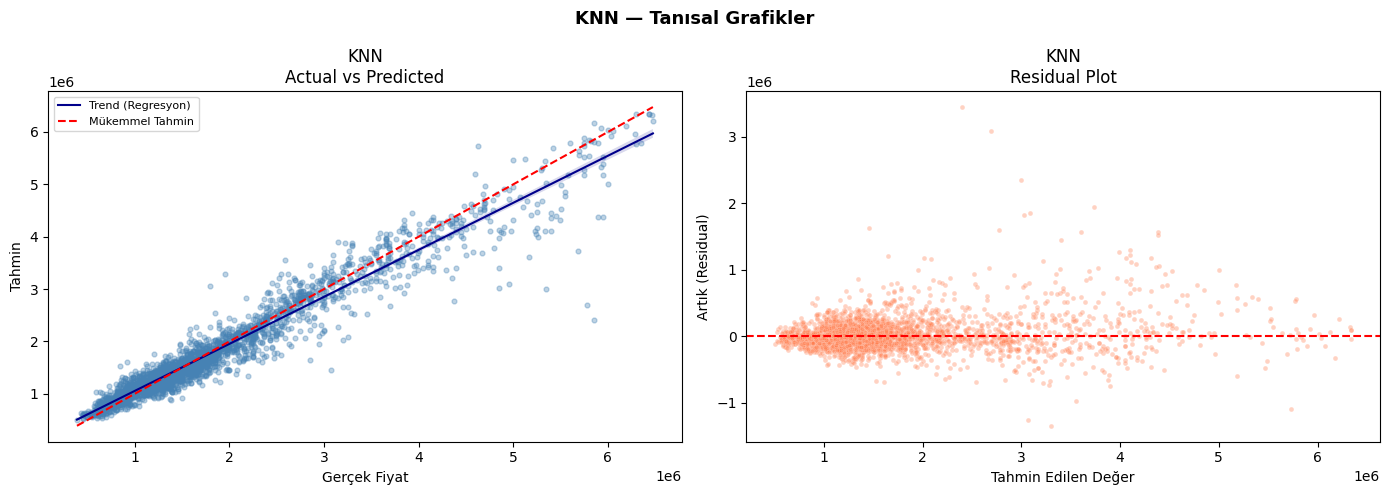

In [33]:
model_name = f'KNN'
y_pred     = predictions[model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{model_name} — Tanısal Grafikler', fontsize=13, fontweight='bold')

plot_lm_residual(y_test_orig, y_pred, model_name, axes)

plt.tight_layout()
plt.show()

## SVR

In [34]:
# # ── 7) SVR ──────────────────────────────────────
print("\n  SVR eğitiliyor (büyük veride yavaş olabilir)...")
svr_gs = GridSearchCV(
    make_pipeline(SVR()),
    {'model__C':       np.arange(0.1,4,0.1),
     'model__kernel':  ['rbf', 'linear']},
    cv=cv_inner, scoring='neg_mean_squared_error', n_jobs=-1
)
svr_gs.fit(X_train, y_train_log)
print(f"  SVR {svr_gs.best_params_}")
predictions['SVR'] = np.expm1(svr_gs.best_estimator_.predict(X_test))
add_result(evaluation_results, f"SVR", y_test_orig, predictions['SVR'], f"{svr_gs.best_params_}")


  SVR eğitiliyor (büyük veride yavaş olabilir)...
  SVR {'model__C': np.float64(3.9000000000000004), 'model__kernel': 'rbf'}
  SVR                                                     | MSE:111,700,285,743 | RMSE:   334,216 | MAE:   200,859 | R²: 0.9076 | {'model__C': np.float64(3.9000000000000004), 'model__kernel': 'rbf'}


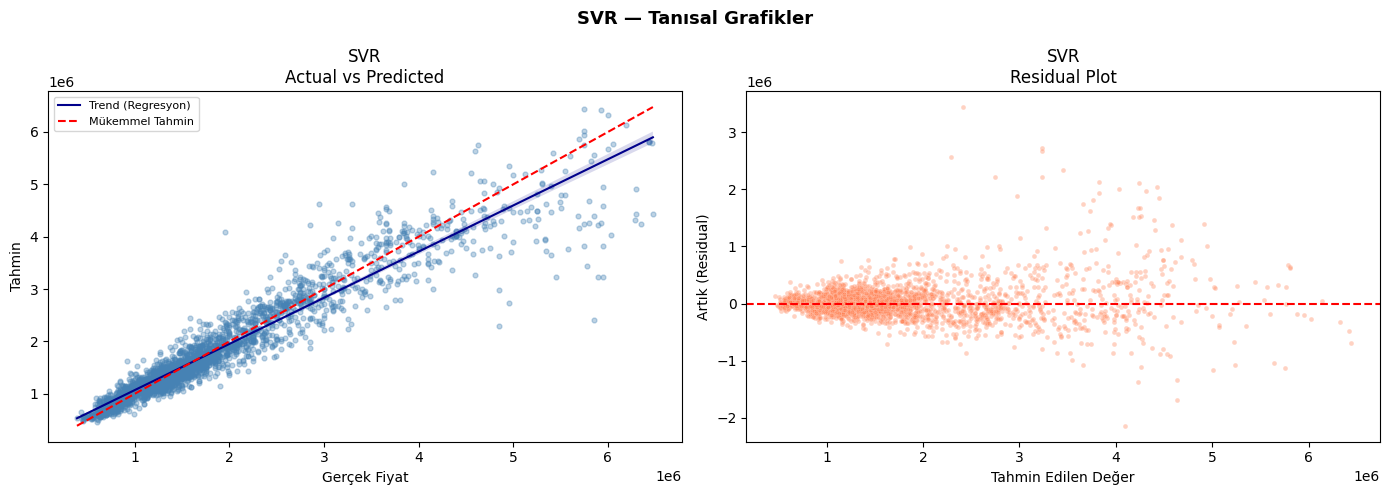

In [35]:
model_name = f'SVR'
y_pred     = predictions[model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{model_name} — Tanısal Grafikler', fontsize=13, fontweight='bold')

plot_lm_residual(y_test_orig, y_pred, model_name, axes)

plt.tight_layout()
plt.show()

## MLP


In [36]:
# ── 8) MLP —
mlp_gs = GridSearchCV(
    make_pipeline(MLPRegressor(max_iter=1000, random_state=42, early_stopping=True)),
    {'model__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64), (256, 128)],
     'model__alpha':              [0.0001, 0.001, 0.01],
     'model__learning_rate_init': [0.001, 0.01]},
    cv=cv_inner, scoring='neg_mean_squared_error', n_jobs=-1
)
mlp_gs.fit(X_train, y_train_log)
print(f"  MLP {mlp_gs.best_params_}")
predictions['MLP'] = np.expm1(mlp_gs.best_estimator_.predict(X_test))
add_result(evaluation_results, f"MLP", y_test_orig, predictions['MLP'],f"{mlp_gs.best_params_}")

  MLP {'model__alpha': 0.01, 'model__hidden_layer_sizes': (64, 32), 'model__learning_rate_init': 0.001}
  MLP                                                     | MSE:163,498,347,655 | RMSE:   404,349 | MAE:   234,994 | R²: 0.8647 | {'model__alpha': 0.01, 'model__hidden_layer_sizes': (64, 32), 'model__learning_rate_init': 0.001}


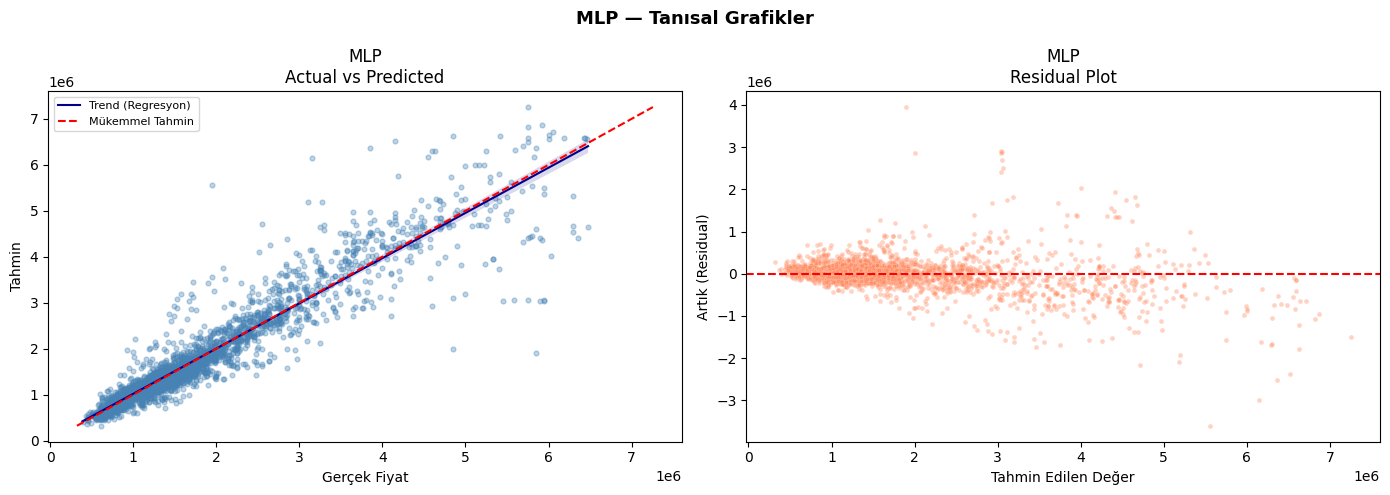

In [37]:
model_name = f'MLP'
y_pred     = predictions[model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{model_name} — Tanısal Grafikler', fontsize=13, fontweight='bold')

plot_lm_residual(y_test_orig, y_pred, model_name, axes)

plt.tight_layout()
plt.show()

## Karar Ağaçları

In [38]:
# ── 9) Decision Tree ─────────────────────────────────────────
dt_gs = GridSearchCV(
    make_pipeline(DecisionTreeRegressor(random_state=42)),
    {'model__max_depth':         [3, 5, 7, 10, None],
     'model__min_samples_split': [2, 5, 10],
     'model__min_samples_leaf':  [1, 2, 4]},
    cv=cv_inner, scoring='neg_mean_squared_error', n_jobs=-1
)
dt_gs.fit(X_train, y_train_log)
print(f"\n  Decision Tree {dt_gs.best_params_}")
predictions['Decision Tree'] = np.expm1(dt_gs.best_estimator_.predict(X_test))
add_result(evaluation_results, "Decision Tree", y_test_orig, predictions['Decision Tree'],f"{dt_gs.best_params_}")


  Decision Tree {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}
  Decision Tree                                           | MSE:91,292,983,989 | RMSE:   302,147 | MAE:   183,628 | R²: 0.9245 | {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}


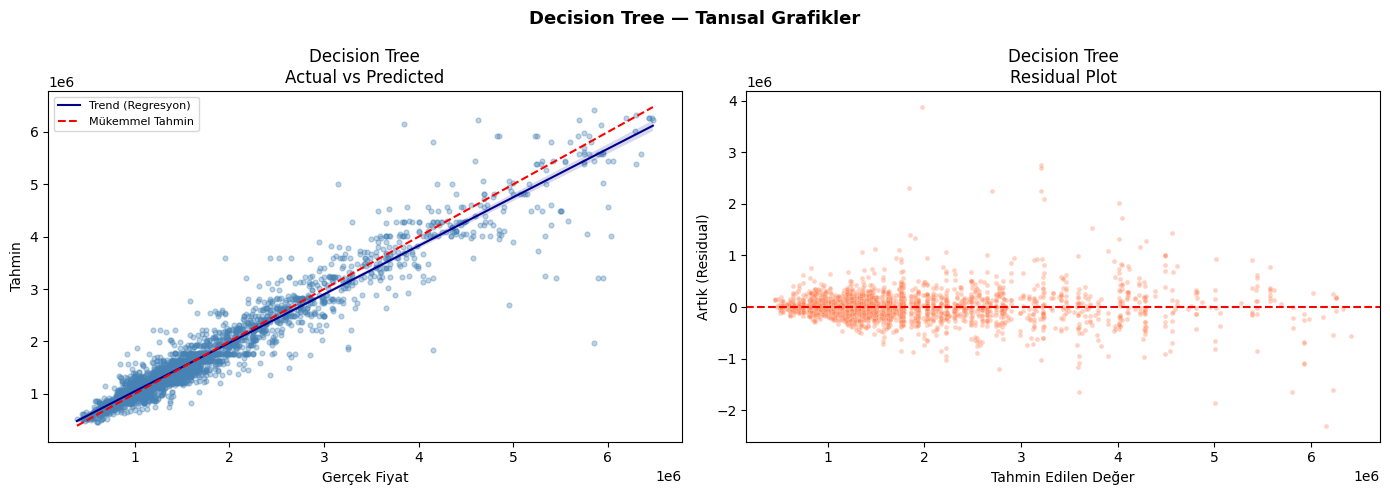

In [39]:
model_name = f'Decision Tree'
y_pred     = predictions[model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{model_name} — Tanısal Grafikler', fontsize=13, fontweight='bold')

plot_lm_residual(y_test_orig, y_pred, model_name, axes)

plt.tight_layout()
plt.show()

## Bagging

In [40]:
# ── 10) Bagging ──────────────────────────────────────────────
bag_gs = GridSearchCV(
    make_pipeline(BaggingRegressor(random_state=42, n_jobs=-1)),
    {'model__n_estimators': [10, 50, 100],
     'model__max_samples':  [0.6, 0.8, 1.0],
     'model__max_features': [0.6, 0.8, 1.0]},
    cv=cv_inner, scoring='neg_mean_squared_error', n_jobs=-1
)
bag_gs.fit(X_train, y_train_log)
print(f"  Bagging {bag_gs.best_params_}")
predictions['Bagging'] = np.expm1(bag_gs.best_estimator_.predict(X_test))
add_result(evaluation_results, f"Bagging", y_test_orig, predictions['Bagging'] ,f"{bag_gs.best_params_}")


  Bagging {'model__max_features': 0.8, 'model__max_samples': 0.8, 'model__n_estimators': 100}
  Bagging                                                 | MSE:64,825,135,887 | RMSE:   254,608 | MAE:   147,410 | R²: 0.9464 | {'model__max_features': 0.8, 'model__max_samples': 0.8, 'model__n_estimators': 100}


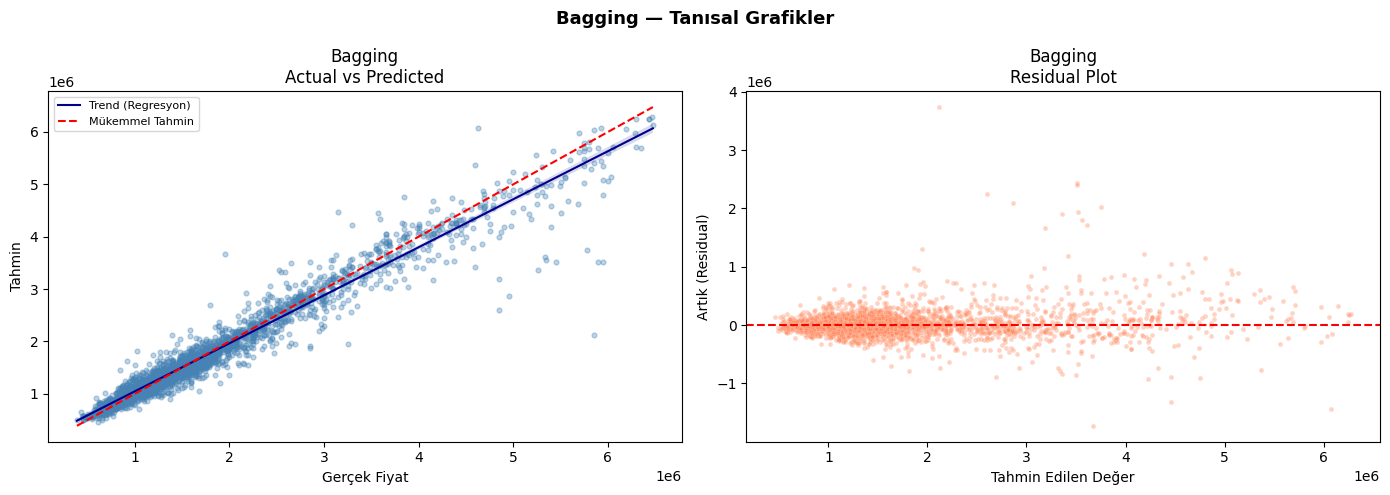

In [41]:
model_name = f'Bagging'
y_pred     = predictions[model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{model_name} — Tanısal Grafikler', fontsize=13, fontweight='bold')

plot_lm_residual(y_test_orig, y_pred, model_name, axes)

plt.tight_layout()
plt.show()

## Random Forest

In [42]:
# Random Forest — cuML GPU (kuruluysa bu bloğu kullan)
# ────────────────────────────────────────────────────────────
try:
    from cuml.ensemble import RandomForestRegressor as cuRF
    import cupy as cp
    from sklearn.base import BaseEstimator, RegressorMixin

    # cuML sklearn-uyumlu wrapper
    class cuRFWrapper(BaseEstimator, RegressorMixin):
        def __init__(self, n_estimators=100, max_depth=10):
            self.n_estimators = n_estimators
            self.max_depth    = max_depth
        def fit(self, X, y):
            self._model = cuRF(n_estimators=self.n_estimators,
                               max_depth=self.max_depth, random_state=42)
            self._model.fit(cp.array(X.astype('float32')),
                            cp.array(y.astype('float32')))
            return self
        def predict(self, X):
            return cp.asnumpy(self._model.predict(cp.array(X.astype('float32'))))

    curf_gs = GridSearchCV(
        make_pipeline(cuRFWrapper()),
        {'model__n_estimators': [100, 200], 'model__max_depth': [5, 10, 20]},
        cv=cv_inner, scoring='neg_mean_squared_error', n_jobs=1
    )
    curf_gs.fit(X_train, y_train_log)
    predictions['RF'] = np.expm1(curf_gs.best_estimator_.predict(X_test))
    add_result(evaluation_results, "RF", y_test_orig, predictions['RF'],f"{curf_gs.best_params_}")
except ImportError:
    print("  cuML yok, sklearn RF kullanıldı")
except OSError as e:
    print(f"  cuML GPU kütüphanesi yüklenirken hata oluştu: {e}. RF modeli atlanıyor.")

  RF                                                      | MSE:65,845,604,137 | RMSE:   256,604 | MAE:   143,625 | R²: 0.9455 | {'model__max_depth': 20, 'model__n_estimators': 200}   


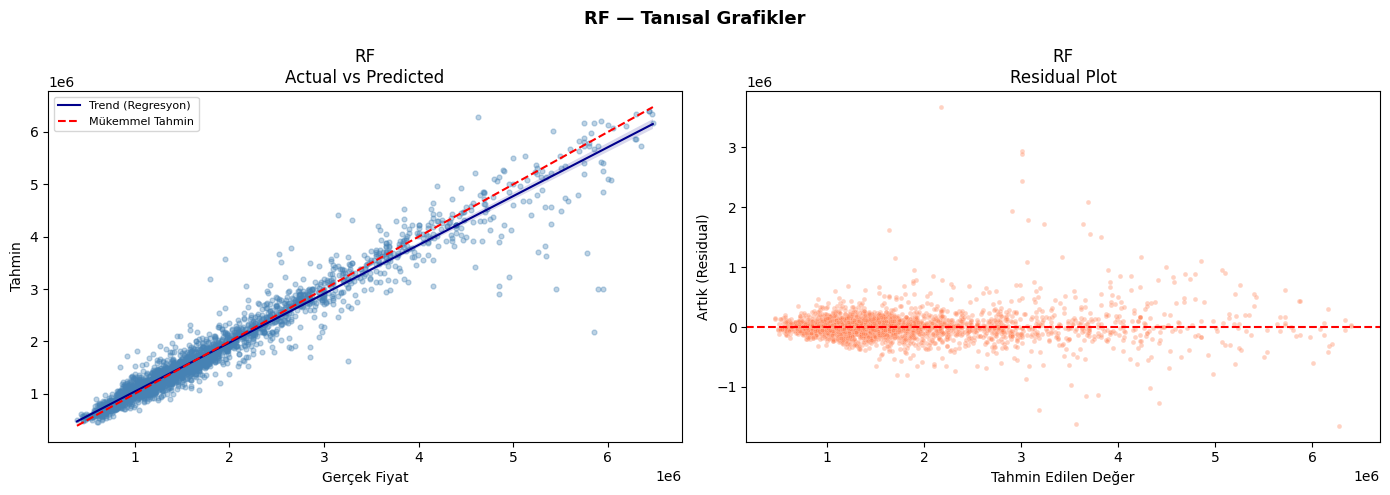

In [43]:
model_name = f'RF'
y_pred     = predictions[model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{model_name} — Tanısal Grafikler', fontsize=13, fontweight='bold')

plot_lm_residual(y_test_orig, y_pred, model_name, axes)

plt.tight_layout()
plt.show()

## Gradient Boosting

In [44]:
# ── 12) Gradient Boosting — sklearn CPU ──────────────────────
gb_gs = GridSearchCV(
    make_pipeline(GradientBoostingRegressor(random_state=42)),
    {'model__n_estimators':  [100, 200],
     'model__learning_rate': [0.05, 0.1, 0.2],
     'model__max_depth':     [3, 5],
     'model__subsample':     [0.8, 1.0]},
    cv=cv_inner, scoring='neg_mean_squared_error', n_jobs=-1
)
gb_gs.fit(X_train, y_train_log)
print(f"  Gradient Boosting {gb_gs.best_params_}")
predictions['Gradient Boosting'] = np.expm1(gb_gs.best_estimator_.predict(X_test))
add_result(evaluation_results, "Gradient Boosting", y_test_orig, predictions['Gradient Boosting'],f"{gb_gs.best_params_}")

  Gradient Boosting {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}
  Gradient Boosting                                       | MSE:61,845,623,282 | RMSE:   248,688 | MAE:   144,200 | R²: 0.9488 | {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}


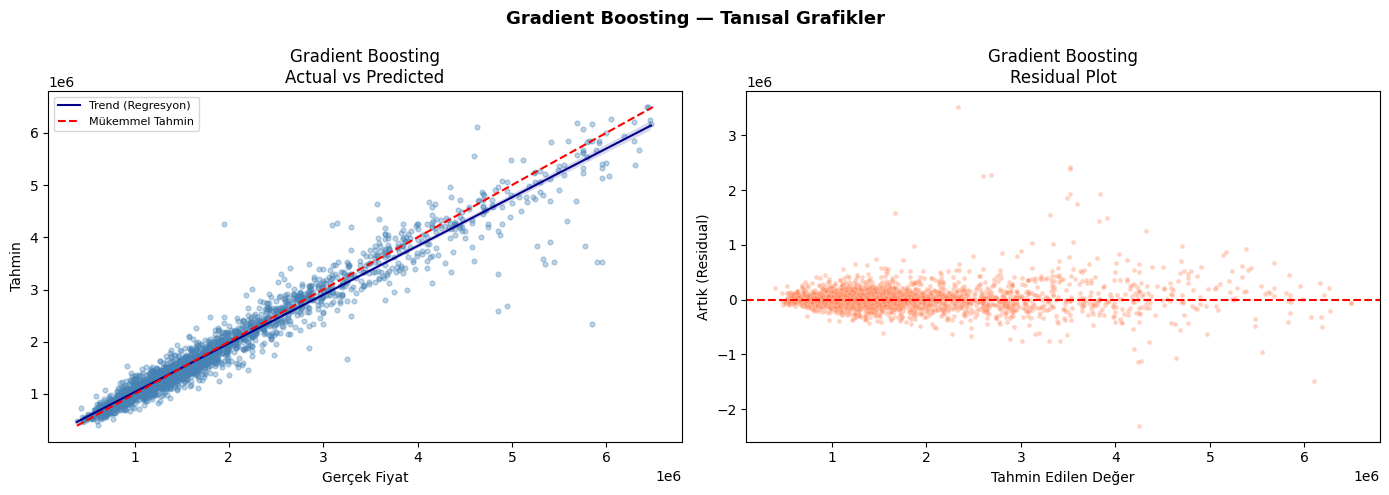

In [45]:
model_name = f'Gradient Boosting'
y_pred     = predictions[model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{model_name} — Tanısal Grafikler', fontsize=13, fontweight='bold')

plot_lm_residual(y_test_orig, y_pred, model_name, axes)

plt.tight_layout()
plt.show()

## XGBoost

In [46]:
# XGBoost GPU
# ────────────────────────────────────────────────────────────
try:
    import xgboost as xgb
    xgb_gs = GridSearchCV(
        make_pipeline(xgb.XGBRegressor(device='cuda', tree_method='hist',
                                       random_state=42, verbosity=0)),
        {'model__n_estimators':  [100, 200, 500],
         'model__learning_rate': [0.05, 0.1, 0.2],
         'model__max_depth':     [3, 5, 7],
         'model__subsample':     [0.8, 1.0],
         'model__colsample_bytree': [0.8, 1.0]},
        cv=cv_inner, scoring='neg_mean_squared_error', n_jobs=1
    )
    xgb_gs.fit(X_train, y_train_log)
    print(f"  XGBoost {xgb_gs.best_params_}")
    predictions['XGBoost'] = np.expm1(xgb_gs.best_estimator_.predict(X_test))
    add_result(evaluation_results, f"XGB", y_test_orig, predictions['XGBoost'],f"{xgb_gs.best_params_}")
except ImportError:
    print("  XGBoost yok")
except OSError as e:
    print(f"  XGBoost GPU kütüphanesi yüklenirken hata oluştu: {e}. XGBoost modeli atlanıyor.")

  XGBoost {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 500, 'model__subsample': 1.0}
  XGB                                                     | MSE:60,753,578,948 | RMSE:   246,482 | MAE:   137,544 | R²: 0.9497 | {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 500, 'model__subsample': 1.0}


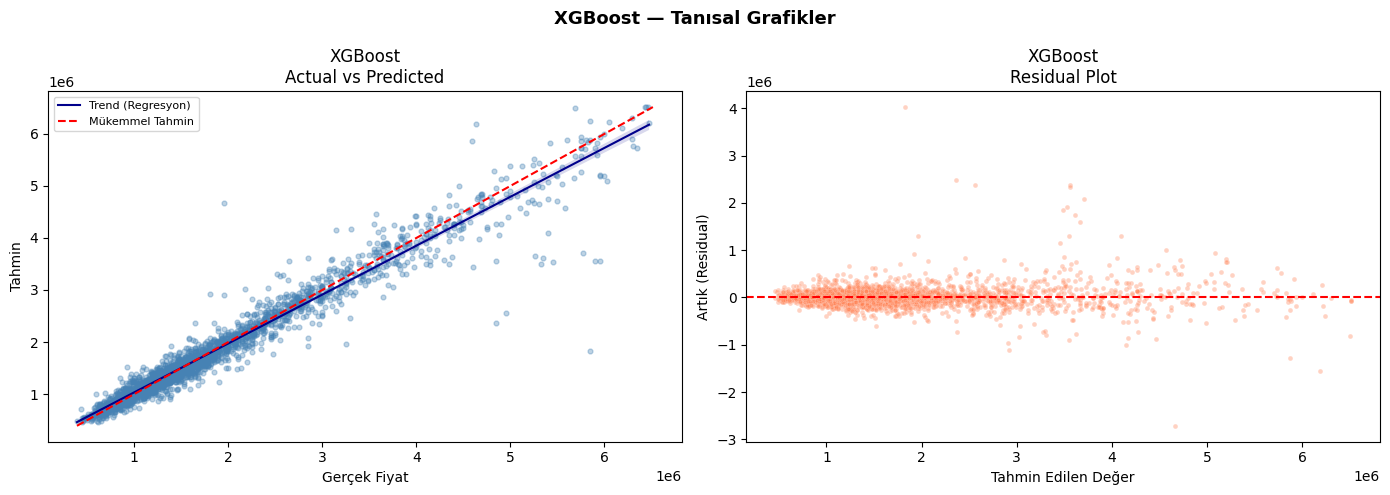

In [47]:
model_name = f'XGBoost'
y_pred     = predictions[model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{model_name} — Tanısal Grafikler', fontsize=13, fontweight='bold')

plot_lm_residual(y_test_orig, y_pred, model_name, axes)

plt.tight_layout()
plt.show()

# Sonuçlar

In [48]:
# ─────────────────────────────────────────────────────────────
# SONUÇLAR
# ─────────────────────────────────────────────────────────────
print("Tüm Modeller Karşılaştırması (Son Fold, Log→Orijinal Skala)")
print(evaluation_results.to_string(index=False))

Tüm Modeller Karşılaştırması (Son Fold, Log→Orijinal Skala)
            Model          MSE      RMSE       MAE     R2                                                                                                                                Parameters
 Lineer Regresyon 1.340693e+11 366154.81 221445.54 0.8891                                                                                                                                   Default
              PCR 1.340693e+11 366154.81 221445.54 0.8891                                                                                                                                    (10pc)
              PLS 1.341267e+11 366233.15 221566.97 0.8890                                                                                                                                     (7pc)
            Ridge 1.340697e+11 366155.33 221445.89 0.8891                                                                                                   